# Binocular Overlap Sweep — Vision Comparison

This notebook visualizes what the virtual rodent **sees** under each experimental
condition in the binocular overlap sweep:

| Condition | `eye_angle_offset` | Overlap |
|-----------|-------------------|----------|
| Monocular frontal | N/A | Single 80° camera |
| Full overlap | 0.0 rad | 80° |
| Current default | 0.2 rad | 57° |
| Rat-like (high) | 0.262 rad | 50° |
| Rat-like (low) | 0.349 rad | 40° |
| Narrow | 0.524 rad | 20° |
| No overlap | 0.698 rad | 0° |

For each condition we render:
1. Left eye and right eye images separately (RGB, 64×64)
2. A top-down schematic diagram of the binocular visual field geometry

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
import jax
import jax.numpy as jp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge, FancyArrowPatch
import numpy as np
from tqdm import tqdm

from vnl_playground.tasks.rodent.run_gap_vision import RunGapVision, default_config
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
from mujoco.mjx.warp.types import DATA_NON_VMAP

## 1. Define Experimental Conditions

In [3]:
# Each condition: (label, binocular?, eye_angle_offset, overlap_deg)
CONDITIONS = [
    ("Monocular\nfrontal", False, None, None),
    ("Full overlap\n80°", True, 0.0, 80),
    ("Default\n57°", True, 0.2, 57),
    ("Rat-like (high)\n50°", True, 0.262, 50),
    ("Rat-like (low)\n40°", True, 0.349, 40),
    ("Narrow\n20°", True, 0.524, 20),
    ("No overlap\n0°", True, 0.698, 0),
]

WIDTH, HEIGHT = 64, 64  # render resolution (larger than 32 for visualization)
NWORLD = 1

print(f"Rendering {len(CONDITIONS)} conditions at {WIDTH}x{HEIGHT} RGB")

Rendering 7 conditions at 64x64 RGB


## 2. Create Environments and Renderers

In [4]:
def add_batch_dim(data):
    """Add a leading nworld=1 dimension to mjx.Data, skipping non-vmap fields."""

    def _maybe_expand(path, x):
        parts = [p.name for p in path if hasattr(p, "name") and p.name != "_impl"]
        attr = "__".join(parts)
        if attr in DATA_NON_VMAP:
            return x
        return x[None, ...]

    return jax.tree.map_with_path(_maybe_expand, data)


envs = {}  # label -> env
renderers = {}  # label -> dict of renderers

for label, binocular, offset, overlap_deg in tqdm(CONDITIONS, desc="Building envs"):
    cfg = default_config()
    cfg.mujoco_impl = "warp"
    cfg.use_mesh_platforms = True
    cfg.aesthetic = "outdoor_natural"
    cfg.binocular = binocular
    if offset is not None:
        cfg.eye_angle_offset = offset

    env = RunGapVision(config=cfg)
    envs[label] = env

    if binocular:
        # Create separate renderers for left and right eyes
        left_r = JaxVisionRenderer(
            mj_model=env.mj_model,
            mjx_model=env.mjx_model,
            nworld=NWORLD,
            width=WIDTH,
            height=HEIGHT,
            grayscale=False,
            render_depth=False,
            use_textures=True,
            use_shadows=True,
            camera_name="eye_left-rodent",
        )
        right_r = JaxVisionRenderer(
            mj_model=env.mj_model,
            mjx_model=env.mjx_model,
            nworld=NWORLD,
            width=WIDTH,
            height=HEIGHT,
            grayscale=False,
            render_depth=False,
            use_textures=True,
            use_shadows=True,
            camera_name="eye_right-rodent",
        )
        renderers[label] = {"left": left_r, "right": right_r}
    else:
        # Monocular: single egocentric camera
        ego_r = JaxVisionRenderer(
            mj_model=env.mj_model,
            mjx_model=env.mjx_model,
            nworld=NWORLD,
            width=WIDTH,
            height=HEIGHT,
            grayscale=False,
            render_depth=False,
            use_textures=True,
            use_shadows=True,
            camera_name="egocentric-rodent",
        )
        renderers[label] = {"ego": ego_r}

print(f"Created {len(envs)} environments with renderers.")

Building envs:  14%|█▍        | 1/7 [00:00<00:00,  8.88it/s]

Warp 1.13.0.dev20260302 initialized:
   Git commit: 2675d53530597430af87c7425a1bbb40a2c5453a
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 5090" (31 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.13.0.dev20260302
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Module mujoco.mjx.third_party.mujoco_warp._src.render_util 9cda0d9 load on device 'cuda:0' took 0.36 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.io 4ae9eac load on device 'cuda:0' took 1.57 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.bvh 4527052 load on device 'cuda:0' took 0.43 ms  (cached)


Building envs: 100%|██████████| 7/7 [00:00<00:00, 13.94it/s]

Created 7 environments with renderers.


## 3. Run Short Rollout and Render Vision

In [5]:
N_ROLLOUT_STEPS = 30  # run a few steps so the rodent is in a natural pose near a gap

rendered_images = {}  # label -> {"left": img, "right": img} or {"ego": img}

for label, binocular, offset, overlap_deg in tqdm(CONDITIONS, desc="Rendering"):
    env = envs[label]
    rng = jax.random.PRNGKey(42)
    state = jax.jit(env.reset)(rng)
    step_fn = jax.jit(env.step)

    # Run a few zero-action steps
    for _ in range(N_ROLLOUT_STEPS):
        state = step_fn(state, jp.zeros(env.action_size))

    batched_data = add_batch_dim(state.data)

    if binocular:
        left_img = np.array(jax.jit(renderers[label]["left"].render)(batched_data)[0])
        right_img = np.array(jax.jit(renderers[label]["right"].render)(batched_data)[0])
        rendered_images[label] = {"left": left_img, "right": right_img}
    else:
        ego_img = np.array(jax.jit(renderers[label]["ego"].render)(batched_data)[0])
        rendered_images[label] = {"ego": ego_img}

print("All conditions rendered.")

Rendering:   0%|          | 0/7 [00:00<?, ?it/s]

Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 0.24 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 3.52 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.25 ms  (cached)
Module _nxn_broadphase__locals__kernel_ea6098d7 ea6098d load on device 'cuda:0' took 0.24 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_ba2335e3 ba2335e load on device 'cuda:0' took 1.01 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_47e99e6d 47e99e6 load on device 'cuda:0' took 1.10 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_201d3c22 201d3c2 load on device 'cuda:0' took 0.87 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_4d39dd93 4d39dd9 load on device 'cuda:0' took 0.88 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_f0f83fea f0f83fe load on device 'cuda:0' took 1.00 ms  (cached)
Module _primitive_narrowphase__locals

Rendering:  14%|█▍        | 1/7 [00:03<00:20,  3.36s/it]

Module render__locals___render_megakernel_d372eea5 d372eea load on device 'cuda:0' took 0.67 ms  (cached)


Rendering: 100%|██████████| 7/7 [00:18<00:00,  2.63s/it]

All conditions rendered.


## 4. Side-by-Side Vision Comparison

Each column is one condition. Top row = left eye (or egocentric), bottom row = right eye.

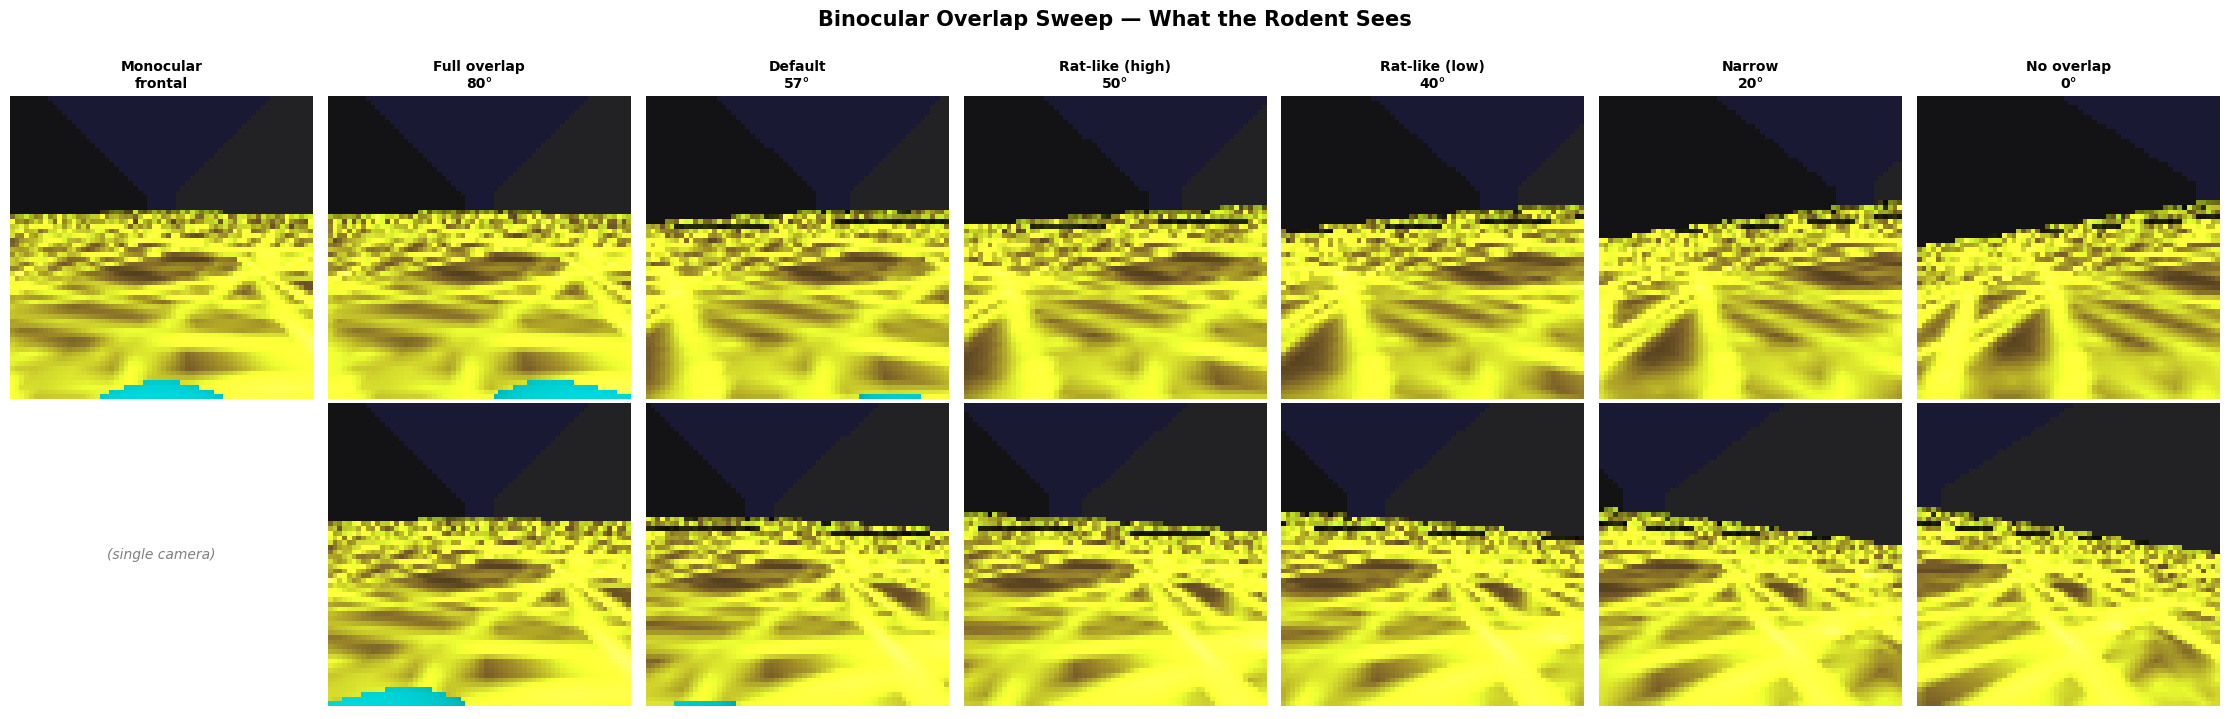

In [6]:
n_cond = len(CONDITIONS)
fig, axes = plt.subplots(2, n_cond, figsize=(3.2 * n_cond, 7))

for col, (label, binocular, offset, overlap_deg) in enumerate(CONDITIONS):
    imgs = rendered_images[label]

    if binocular:
        axes[0, col].imshow(imgs["left"])
        axes[1, col].imshow(imgs["right"])
    else:
        # Monocular: show the same ego image in both rows
        axes[0, col].imshow(imgs["ego"])
        axes[1, col].text(
            0.5,
            0.5,
            "(single camera)",
            transform=axes[1, col].transAxes,
            ha="center",
            va="center",
            fontsize=10,
            color="gray",
            fontstyle="italic",
        )
        axes[1, col].set_facecolor("#f0f0f0")

    axes[0, col].set_title(label, fontsize=10, fontweight="bold")
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Left Eye", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Right Eye", fontsize=12, fontweight="bold")

plt.suptitle(
    "Binocular Overlap Sweep — What the Rodent Sees",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

## 5. Visual Field Geometry Diagrams

Top-down schematic showing how the left and right eye fields overlap for each
binocular condition. The shaded region in the center is the binocular overlap zone.

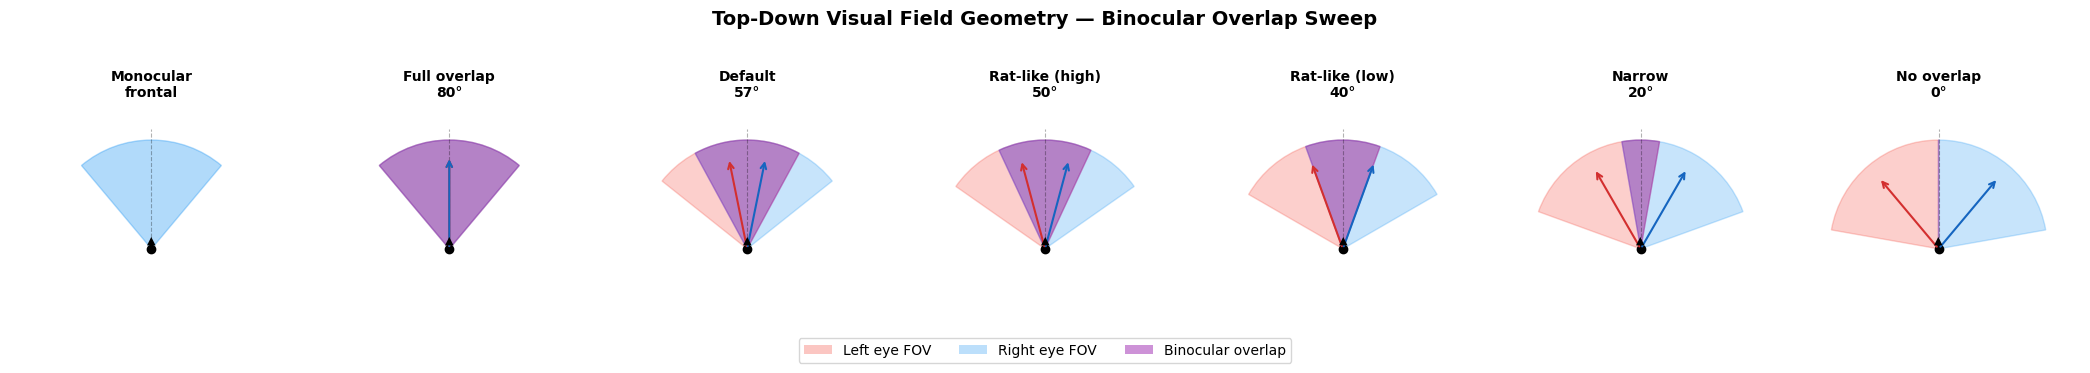

In [7]:
def draw_visual_field(ax, offset_deg, fovy=80, title="", overlap_deg=None):
    """Draw a top-down visual field diagram for one binocular condition.

    The rodent faces upward (+y). Each eye's FOV is a wedge centered on its
    gaze direction (forward ± offset_deg).
    """
    half_fov = fovy / 2

    if offset_deg is None:
        # Monocular: single forward-facing wedge
        wedge = Wedge(
            (0, 0),
            1.0,
            theta1=90 - half_fov,
            theta2=90 + half_fov,
            alpha=0.35,
            color="#2196F3",
            label="Egocentric",
        )
        ax.add_patch(wedge)
    else:
        # Left eye: gaze direction = 90 + offset_deg (yawed left from forward)
        left_center = 90 + offset_deg
        left_wedge = Wedge(
            (0, 0),
            1.0,
            theta1=left_center - half_fov,
            theta2=left_center + half_fov,
            alpha=0.25,
            color="#F44336",
            label="Left eye",
        )
        ax.add_patch(left_wedge)

        # Right eye: gaze direction = 90 - offset_deg (yawed right from forward)
        right_center = 90 - offset_deg
        right_wedge = Wedge(
            (0, 0),
            1.0,
            theta1=right_center - half_fov,
            theta2=right_center + half_fov,
            alpha=0.25,
            color="#2196F3",
            label="Right eye",
        )
        ax.add_patch(right_wedge)

        # Draw the overlap region
        actual_overlap = fovy - 2 * offset_deg
        if actual_overlap > 0:
            overlap_start = 90 - actual_overlap / 2
            overlap_end = 90 + actual_overlap / 2
            overlap_wedge = Wedge(
                (0, 0),
                1.0,
                theta1=overlap_start,
                theta2=overlap_end,
                alpha=0.4,
                color="#9C27B0",
                label=f"Overlap {actual_overlap:.0f}°",
            )
            ax.add_patch(overlap_wedge)

        # Draw gaze direction arrows
        for angle, color in [(left_center, "#D32F2F"), (right_center, "#1565C0")]:
            rad = np.radians(angle)
            dx, dy = 0.85 * np.cos(rad), 0.85 * np.sin(rad)
            ax.annotate(
                "",
                xy=(dx, dy),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5),
            )

    # Draw the forward direction
    ax.plot([0, 0], [0, 1.1], "k--", alpha=0.3, lw=0.8)

    # Rodent head marker
    ax.plot(0, 0, "ko", markersize=6)
    ax.annotate("▲", (0, 0.08), ha="center", va="center", fontsize=8, color="k")

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.axis("off")


# Draw all conditions
fig, axes = plt.subplots(1, n_cond, figsize=(3 * n_cond, 3.5))

for col, (label, binocular, offset, overlap_deg) in enumerate(CONDITIONS):
    if binocular:
        offset_deg = np.degrees(offset)
        draw_visual_field(axes[col], offset_deg, title=label, overlap_deg=overlap_deg)
    else:
        draw_visual_field(axes[col], None, title=label)

# Add a shared legend
legend_elements = [
    mpatches.Patch(facecolor="#F44336", alpha=0.3, label="Left eye FOV"),
    mpatches.Patch(facecolor="#2196F3", alpha=0.3, label="Right eye FOV"),
    mpatches.Patch(facecolor="#9C27B0", alpha=0.5, label="Binocular overlap"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05),
)

plt.suptitle(
    "Top-Down Visual Field Geometry — Binocular Overlap Sweep",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 6. Combined: Vision + Field Diagram per Condition

Each column shows the visual field schematic on top, with left/right eye renders below.

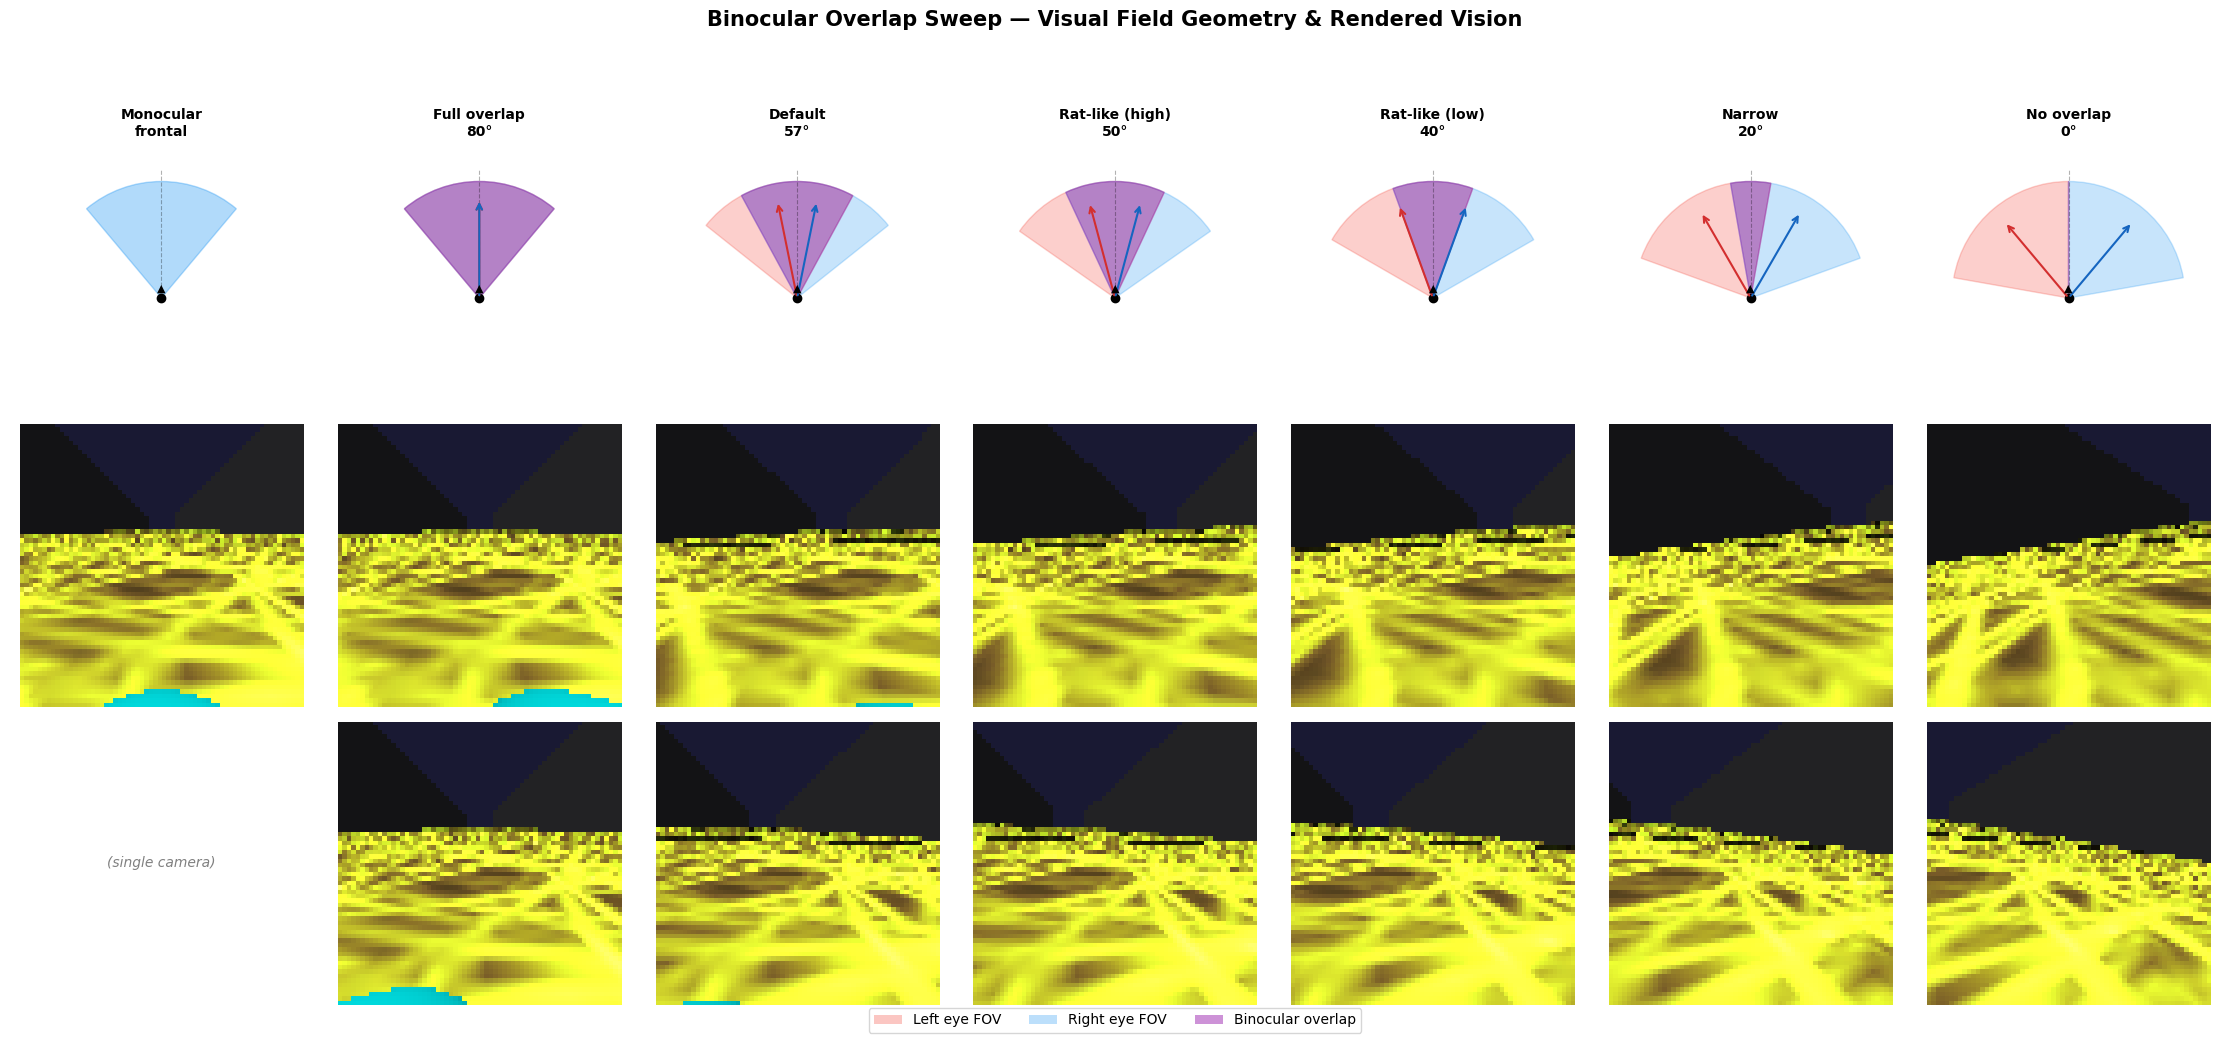

In [8]:
fig, axes = plt.subplots(
    3,
    n_cond,
    figsize=(3.2 * n_cond, 10),
    gridspec_kw={"height_ratios": [1.2, 1, 1]},
)

for col, (label, binocular, offset, overlap_deg) in enumerate(CONDITIONS):
    # Row 0: Visual field diagram
    if binocular:
        offset_deg = np.degrees(offset)
        draw_visual_field(
            axes[0, col], offset_deg, title=label, overlap_deg=overlap_deg
        )
    else:
        draw_visual_field(axes[0, col], None, title=label)

    # Rows 1-2: Rendered vision
    imgs = rendered_images[label]
    if binocular:
        axes[1, col].imshow(imgs["left"])
        axes[2, col].imshow(imgs["right"])
    else:
        axes[1, col].imshow(imgs["ego"])
        axes[2, col].text(
            0.5,
            0.5,
            "(single camera)",
            transform=axes[2, col].transAxes,
            ha="center",
            va="center",
            fontsize=10,
            color="gray",
            fontstyle="italic",
        )
        axes[2, col].set_facecolor("#f0f0f0")

    axes[1, col].axis("off")
    axes[2, col].axis("off")

axes[1, 0].set_ylabel("Left Eye", fontsize=11, fontweight="bold")
axes[2, 0].set_ylabel("Right Eye", fontsize=11, fontweight="bold")

# Shared legend
legend_elements = [
    mpatches.Patch(facecolor="#F44336", alpha=0.3, label="Left eye FOV"),
    mpatches.Patch(facecolor="#2196F3", alpha=0.3, label="Right eye FOV"),
    mpatches.Patch(facecolor="#9C27B0", alpha=0.5, label="Binocular overlap"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
)

plt.suptitle(
    "Binocular Overlap Sweep — Visual Field Geometry & Rendered Vision",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

## 7. Vision Across Multiple Timesteps

Render a few timesteps for each condition to show how the views evolve as the
rodent moves (zero-action rollout — the rodent falls/slides naturally).

In [9]:
SAMPLE_STEPS = [0, 10, 20, 30, 40, 50]  # which rollout steps to render
N_TOTAL_STEPS = max(SAMPLE_STEPS) + 1

# Pick a few representative conditions
SELECTED = [0, 1, 3, 5, 6]  # monocular, full, rat-like high, narrow, no overlap

multi_images = {}  # (label, step) -> {"left": img, "right": img} or {"ego": img}

for idx in tqdm(SELECTED, desc="Multi-step rendering"):
    label, binocular, offset, overlap_deg = CONDITIONS[idx]
    env = envs[label]
    rng = jax.random.PRNGKey(42)
    state = jax.jit(env.reset)(rng)
    step_fn = jax.jit(env.step)

    for step in range(N_TOTAL_STEPS):
        state = step_fn(state, jp.zeros(env.action_size))
        if step in SAMPLE_STEPS:
            batched_data = add_batch_dim(state.data)
            if binocular:
                left = np.array(
                    jax.jit(renderers[label]["left"].render)(batched_data)[0]
                )
                right = np.array(
                    jax.jit(renderers[label]["right"].render)(batched_data)[0]
                )
                multi_images[(label, step)] = {"left": left, "right": right}
            else:
                ego = np.array(jax.jit(renderers[label]["ego"].render)(batched_data)[0])
                multi_images[(label, step)] = {"ego": ego}

print(f"Rendered {len(multi_images)} frames across {len(SELECTED)} conditions.")

Multi-step rendering: 100%|██████████| 5/5 [00:19<00:00,  3.88s/it]

Rendered 30 frames across 5 conditions.


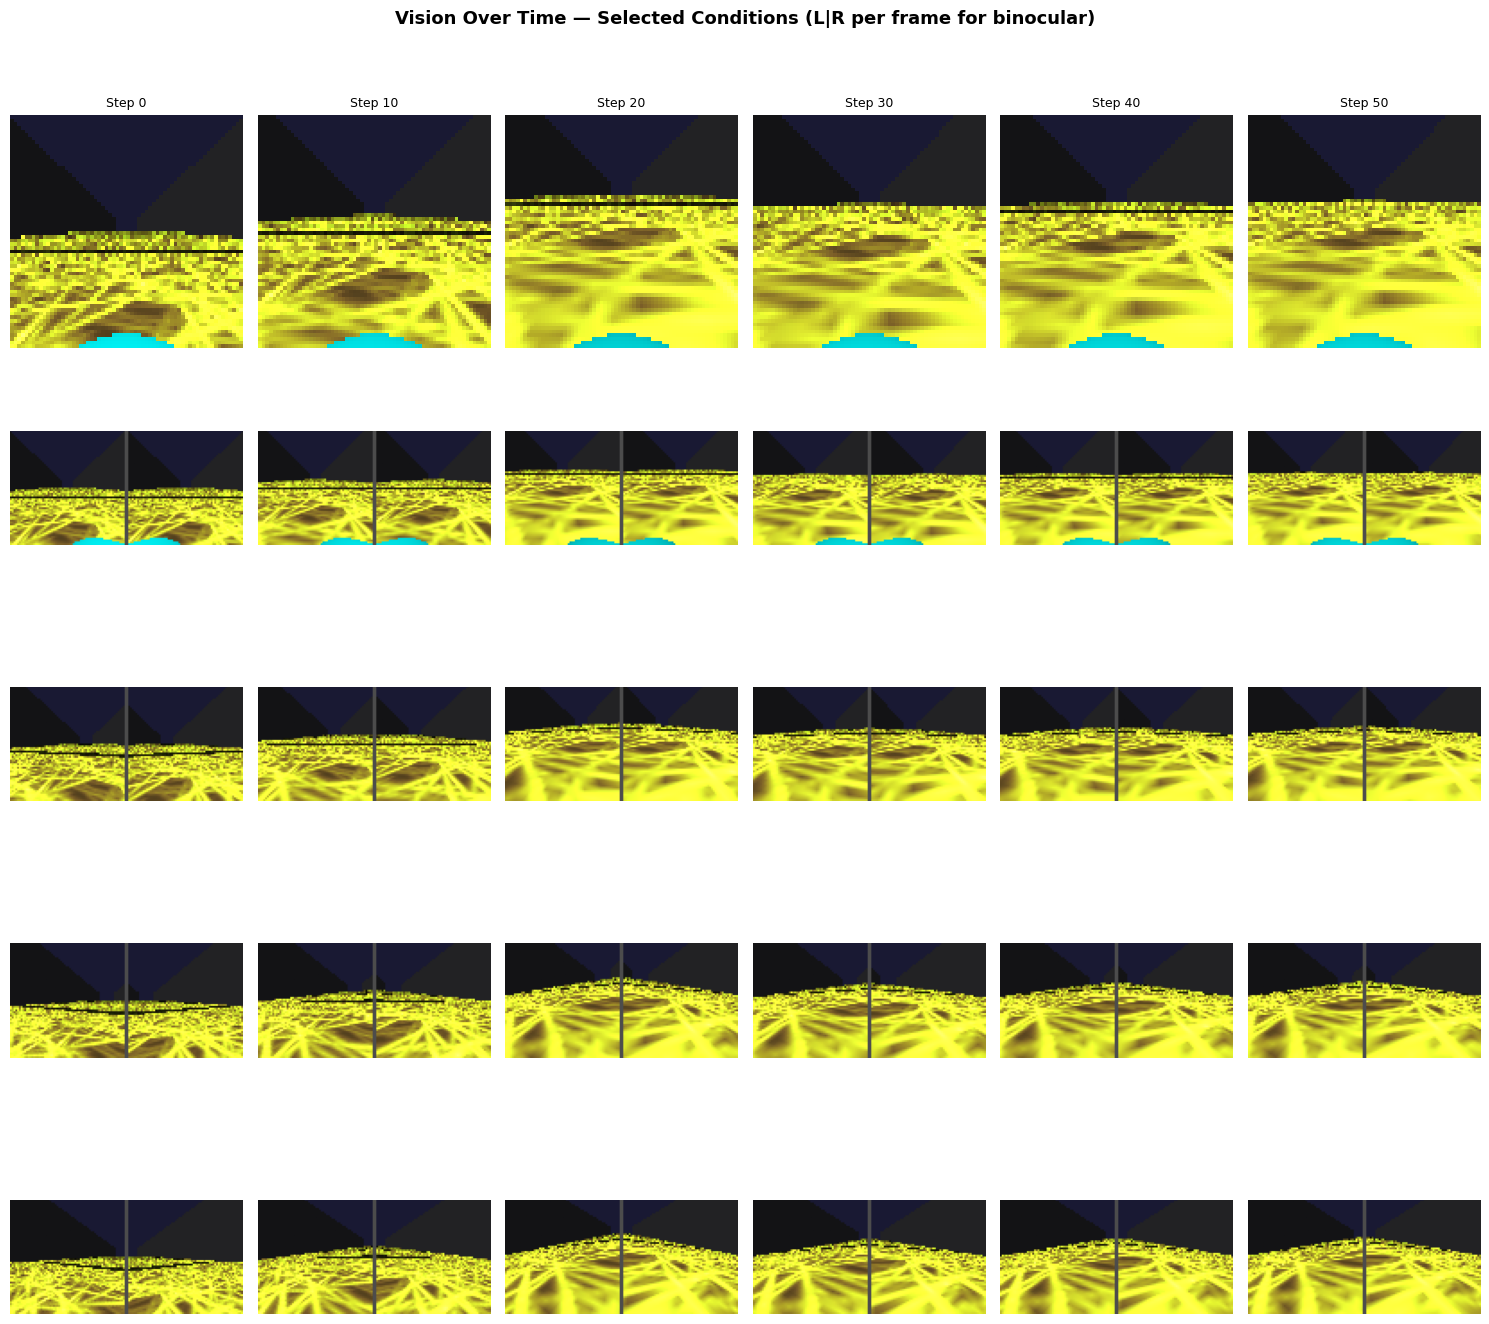

: 

In [ ]:
n_sel = len(SELECTED)
n_steps = len(SAMPLE_STEPS)

fig, axes = plt.subplots(n_sel, n_steps, figsize=(2.5 * n_steps, 2.8 * n_sel))

for row_i, idx in enumerate(SELECTED):
    label, binocular, offset, overlap_deg = CONDITIONS[idx]
    for col_i, step in enumerate(SAMPLE_STEPS):
        imgs = multi_images[(label, step)]
        if binocular:
            # Show left and right side by side with a thin separator
            left = imgs["left"]
            right = imgs["right"]
            sep = np.ones((HEIGHT, 2, 3), dtype=left.dtype) * 0.3
            combined = np.concatenate([left, sep, right], axis=1)
            axes[row_i, col_i].imshow(combined)
        else:
            axes[row_i, col_i].imshow(imgs["ego"])

        axes[row_i, col_i].axis("off")
        if row_i == 0:
            axes[row_i, col_i].set_title(f"Step {step}", fontsize=9)

    axes[row_i, 0].set_ylabel(label, fontsize=9, fontweight="bold")

plt.suptitle(
    "Vision Over Time — Selected Conditions (L|R per frame for binocular)",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

## Notes

**Overlap formula:** `overlap_deg ≈ fovy - 2 × degrees(eye_angle_offset)` (valid for square aspect ratio, 32×32 training images).

**Literature context:**
- Real rat binocular overlap varies widely (40–90°) depending on eye position (Wallace et al. 2013, Nature)
- Rat eyes move independently — up to 40° horizontal divergence
- Our model uses fixed, yoked cameras (primate-like), which is more generous than real rat vision
- The "rat-like" conditions (40–50°) match horizontal-plane estimates from Heesy 2004

**What to look for in training results:**
- As overlap narrows, do agents develop head-bobbing (motion parallax)?
- At what overlap does gap-crossing performance degrade?
- Does monocular frontal outperform binocular (as expected for fixed cameras)?